# Fake Job Posting Detector

This notebook implements a fake job posting detector using standard scikit-learn tools: TF-IDF for text, StandardScaler for numeric features, and logistic regression plus random forest for classification. No Keras, TensorFlow, or XGBoost is used.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid", palette="muted", font_scale=1.05)


In [2]:
df = pd.read_csv('fake_job_postings.csv')
print("Dataset shape:", df.shape)
print("Target distribution:", df["fraudulent"].value_counts())

df.head(3)


Dataset shape: (17880, 18)
Target distribution: fraudulent
0    17014
1      866
Name: count, dtype: int64


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [3]:
# Fill missing text fields and build a combined text feature
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("")

# Concatenate the text columns for each row
available_text_columns = [col for col in text_columns if col in df.columns]
df['text'] = df[available_text_columns].astype(str).apply(lambda row: ' '.join(x for x in row if x), axis=1)

df['text'] = df['text'].str.strip()

print('Empty text rows:', (df['text'].str.len() == 0).sum())
df = df[df['text'].str.len() > 0].copy()

df[['job_id', 'fraudulent', 'text']].head(3)
df['text']

Empty text rows: 0


0        Marketing Intern We're Food52, and we've creat...
1        Customer Service - Cloud Video Production 90 S...
2        Commissioning Machinery Assistant (CMA) Valor ...
3        Account Executive - Washington DC Our passion ...
4        Bill Review Manager SpotSource Solutions LLC i...
                               ...                        
17875    Account Director - Distribution  Vend is looki...
17876    Payroll Accountant WebLinc is the e-commerce p...
17877    Project Cost Control Staff Engineer - Cost Con...
17878    Graphic Designer Nemsia Studios is looking for...
17879    Web Application Developers Vend is looking for...
Name: text, Length: 17880, dtype: str

In [4]:
# Select features for the model
numeric_features = ['telecommuting', 'has_company_logo', 'has_questions']
categorical_features = ['employment_type']

for col in numeric_features + categorical_features:
    if col not in df.columns:
        raise ValueError(f"Missing expected column: {col}")

X = df[numeric_features + categorical_features + ["text"]]
y = df["fraudulent"]

print("Feature columns:", X.columns.tolist())
print("Target sample:", y.value_counts())


Feature columns: ['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'text']
Target sample: fraudulent
0    17014
1      866
Name: count, dtype: int64


In [5]:
# Build preprocessing pipeline
text_transformer = TfidfVectorizer(stop_words="english", max_features=20000)
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, "text"),
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True))


Train shape: (14304, 5) Test shape: (3576, 5)
Train class balance: fraudulent
0    0.951552
1    0.048448
Name: proportion, dtype: float64


--- Logistic Regression ---
Accuracy: 0.9636
              precision    recall  f1-score   support

           0     0.9946    0.9671    0.9806      3403
           1     0.5805    0.8960    0.7045       173

    accuracy                         0.9636      3576
   macro avg     0.7875    0.9315    0.8426      3576
weighted avg     0.9745    0.9636    0.9673      3576



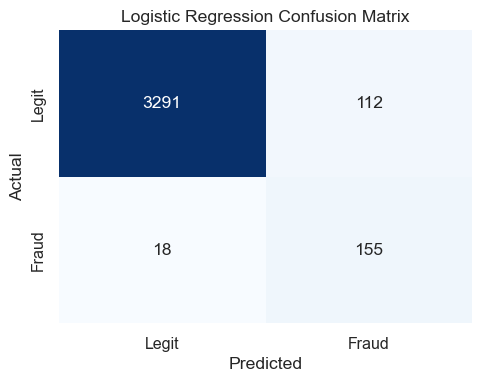

--- Random Forest ---
Accuracy: 0.9793
              precision    recall  f1-score   support

           0     0.9793    0.9994    0.9892      3403
           1     0.9806    0.5838    0.7319       173

    accuracy                         0.9793      3576
   macro avg     0.9799    0.7916    0.8606      3576
weighted avg     0.9793    0.9793    0.9768      3576



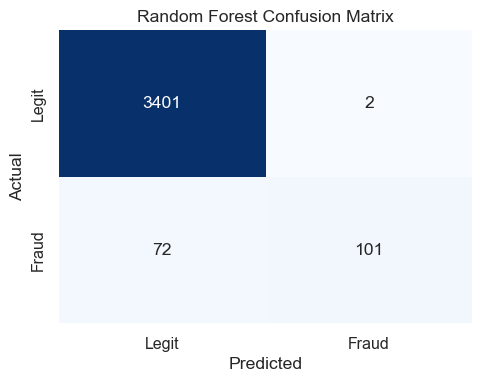

Summary of accuracies:
Logistic Regression: 0.9636
Random Forest: 0.9793


In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)),
    ]),
}

results = {}
for name, model in models.items():
    print(f"--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    results[name] = acc

print("Summary of accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


## Notes and Next Steps

- This notebook uses TF-IDF on combined job posting text plus a few numeric/categorical features.
- The classifiers are standard scikit-learn models: `LogisticRegression` and `RandomForestClassifier`.
- The dataset is imbalanced, so `class_weight="balanced"` is applied to reduce bias toward the majority class.

### Improvements to explore
- Add more categorical fields like `required_experience` and `required_education` to the feature pipeline.
- Try text cleaning and keyword extraction before TF-IDF.
- Tune model hyperparameters with grid search or randomized search.
